In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

## Load Cleaned CSV

In [2]:
df = pd.read_csv('../data/forestfires_clean.csv')
df.head()

,FFMC,DMC,DC,ISI,temp,RH,wind,area,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,log_area
0,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,False,False,False,False,False,False,True,False,False,False,False,0.0
1,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,False,False,False,False,False,False,False,False,False,True,False,0.0
2,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,False,False,False,False,False,False,False,False,False,True,False,0.0
3,91.7,33.3,77.5,9.0,8.3,97,4.0,0.0,False,False,False,False,False,False,True,False,False,False,False,0.0
4,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,False,False,False,False,False,False,True,False,False,False,False,0.0


## Define Features and Target

In [3]:
features = df.columns.drop(['log_area', 'area']).tolist()
features

['FFMC',
 'DMC',
 'DC',
 'ISI',
 'temp',
 'RH',
 'wind',
 'month_aug',
 'month_dec',
 'month_feb',
 'month_jan',
 'month_jul',
 'month_jun',
 'month_mar',
 'month_may',
 'month_nov',
 'month_oct',
 'month_sep']

In [4]:
#add predictors (X) and target (y)
X = df[features]
y = df['log_area']

## Split Train and Test Sets

In [5]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42 )

In [6]:
print("Train: ", X_train.shape)
print("Test: ", X_test.shape)

Train:  (407, 18)
Test:  (102, 18)


## Standard Scaling

In [7]:
continuous_features = [
    'FFMC',
    'DMC',
    'DC',
    'ISI',
    'temp',
    'RH',
    'wind'
]

dummy_features = [
    'month_aug',
    'month_dec',
    'month_feb',
    'month_jan',
    'month_jul',
    'month_jun',
    'month_mar',
    'month_may',
    'month_nov',
    'month_oct',
    'month_sep'
]

In [8]:
# Do not scale dummy features as it will lose meaning

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

scaler.fit(X_train[continuous_features])

X_train_scaled[continuous_features] = scaler.transform(X_train[continuous_features])
X_test_scaled[continuous_features] = scaler.transform(X_test[continuous_features])

X_train_scaled.head()

,FFMC,DMC,DC,ISI,temp,RH,wind,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep
506,-1.470598,-0.824013,0.467498,-1.743887,0.438175,1.516715,1.450909,True,False,False,False,False,False,False,False,False,False,False
137,0.095676,0.299536,0.575089,-0.466706,0.525828,-0.425062,-1.033748,False,False,False,False,False,False,False,False,False,False,True
422,0.278964,1.495623,0.495392,-0.166193,1.612716,-0.728464,-1.033748,True,False,False,False,False,False,False,False,False,False,False
329,0.278964,-0.345579,0.688656,0.159363,-0.105269,0.545826,-0.536816,False,False,False,False,False,False,False,False,False,False,True
412,0.378939,0.833531,0.109660,0.009106,1.332228,-0.364381,-0.536816,False,False,False,False,True,False,False,False,False,False,False


## Build the model

### Model 1

In [9]:
model = LinearRegression() 
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
print(X.head())
print(y.head())

   FFMC   DMC     DC  ISI  temp  RH  wind  month_aug  month_dec  month_feb  \
0  86.2  26.2   94.3  5.1   8.2  51   6.7      False      False      False   
1  90.6  35.4  669.1  6.7  18.0  33   0.9      False      False      False   
2  90.6  43.7  686.9  6.7  14.6  33   1.3      False      False      False   
3  91.7  33.3   77.5  9.0   8.3  97   4.0      False      False      False   
4  89.3  51.3  102.2  9.6  11.4  99   1.8      False      False      False   

   month_jan  month_jul  month_jun  month_mar  month_may  month_nov  \
0      False      False      False       True      False      False   
1      False      False      False      False      False      False   
2      False      False      False      False      False      False   
3      False      False      False       True      False      False   
4      False      False      False       True      False      False   

   month_oct  month_sep  
0      False      False  
1       True      False  
2       True      False  


In [11]:
y_pred = model.predict(X_test_scaled)

r_squared = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Linear Regression Metrics")
print("R^2: ", r_squared)
print("MSE: ", mse)
print("RMSE: ", rmse)


Linear Regression Metrics
R^2:  0.03695649648986188
MSE:  2.440589172453946
RMSE:  1.5622385133051695


- Our model explains only 3.7% of variance in log-units of burned areas.
    - Low R^2 is expected as it aligns with heatmap and plots (ie. all correlations with log_area were close to zero, distribution is skewed and noisy). 
    - Explains that the there may be other factors that contribute to the areas that forest fires burn.
- RMSE of 1.562 (units in log) in a range of 0 to 6.99 is a relatively large error.

## Inspect Learned Coefficients

In [12]:
coef_table = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})
coef_table

,Feature,Coefficient
0,FFMC,0.059630
1,DMC,0.191492
2,DC,-0.490803
3,ISI,-0.030616
4,temp,0.313332
5,RH,0.096634
6,wind,0.067797
7,month_aug,0.420601
8,month_dec,2.515460
9,month_feb,0.310920


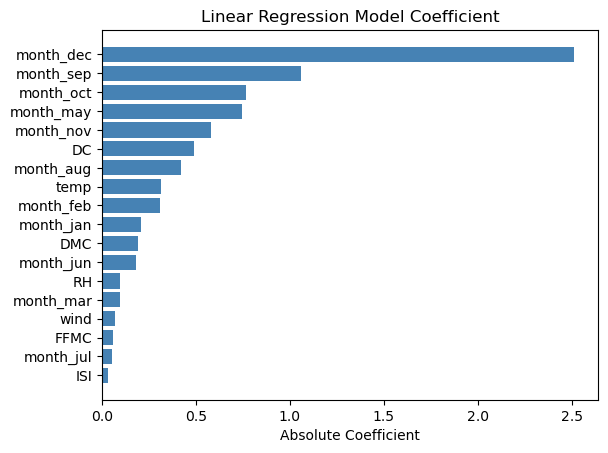

In [13]:
abs_coefs = pd.Series(np.abs(model.coef_), index=X_train.columns).sort_values(ascending=True)

plt.barh(abs_coefs.index, abs_coefs.values, color='steelblue')
plt.xlabel('Absolute Coefficient')
plt.title("Linear Regression Model Coefficient")
plt.show()

- temp (with 0.31) is the predictor that had the stronge positive coefficient over other fire weather indices or conditions.
    - hotter days are associate with larger burned area
    - but still fairly small effect
- DC has the highest negative relationship with -0.5, this could be because the month dummies already explain most the seasonal fire behavior (potential for exploration in the future)
- May, Aug, Sep, Oct, Dec are the months with the largest positive coefficients, better predictors for burned(log) areas.
    - Meaning fires that happened during these months are associated with larger burned areas
    - large jump on month of Dec

## Converting log_area to Original Units

In [14]:
# Converts log_area back to hectares
y_train_orig = np.expm1(y_train)
y_test_orig = np.expm1(y_test)

# Convert predictions to hectares
y_pred_orig = np.expm1(y_pred) # y_pred test set
y_pred_train_orig = np.expm1(model.predict(X_train_scaled)) # y_pred train set

In [15]:
# Calculate metrics in original area unit (hectares)
r_squared_orig = r2_score(y_test_orig, y_pred_orig)
mse_orig = mean_squared_error(y_test_orig, y_pred_orig)
rmse_orig = np.sqrt(mse)


print("Metrics log_area vs area (in hectares)")
print(f"R^2 = {r_squared:.2f} log_area | {r_squared_orig:.2f} hectares")
print(f"MSE = {mse:.2f} log_area | {mse_orig:.2f} hectares")
print(f"RMSE = {rmse:.2f} log_area | {rmse_orig:.2f}  hectares")

Metrics log_area vs area (in hectares)
R^2 = 0.04 log_area | -0.05 hectares
MSE = 2.44 log_area | 7444.03 hectares
RMSE = 1.56 log_area | 1.56  hectares


This shows that converting area in log space helped us in making a better sense of our data. It helped us find even just a small pattern once the feature was log-transformed.
When converted back to hectares, it showed an extreme loss of stability where the large and rare fires affected the model and made it look worse than the average.

## Overfitting Diagnostic (using log_area)

In [16]:
# gap 0-00.05 no overfitting, >0.15 likely overfitting

r2_train = r2_score(y_train, model.predict(X_train_scaled))
r2_test = r2_score(y_test, y_pred)

gap = r2_train - r2_test


# R^2 on original area (hectares)
r2_train_orig = r2_score(y_train_orig, y_pred_train_orig)
r2_test_orig = r2_score(y_test_orig, y_pred_orig)
gap_orig = r2_train_orig - r2_test_orig

print(f"R^2 Train = {r2_train:.2f} log_area | {r2_train_orig:.2f} hectares")
print(f"R^2 Test = {r2_test:.2f} log_area | {r2_test_orig:.2f} hectares")
print(f"Gap = {gap:.2f} log_area | {gap_orig:.2f} hectares")

R^2 Train = 0.06 log_area | -0.02 hectares
R^2 Test = 0.04 log_area | -0.05 hectares
Gap = 0.03 log_area | 0.03 hectares


- Based on above calculations on difference between the R^2 of train and test sets, the model is seeming to perform almost the same as train set. 
- A gap of 0.03 shows no overfitting


### Looking at Residuals

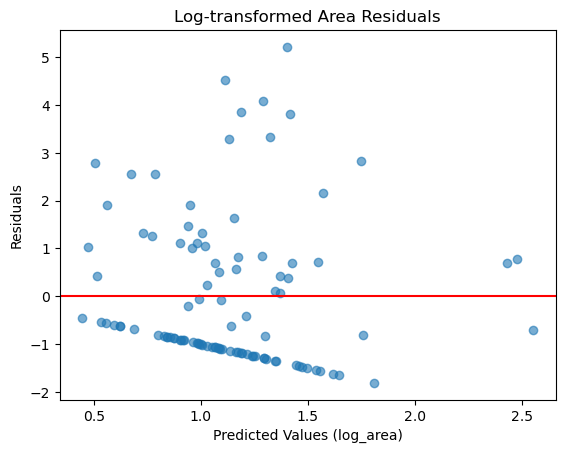

In [17]:
"""
Good linear regression residuals should:
- be centered around zero
- have no clear pattern/random
- have roughly constant spread
"""

residuals = y_test - y_pred

plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red')
plt.xlabel("Predicted Values (log_area)")
plt.ylabel("Residuals")
plt.title("Log-transformed Area Residuals")
plt.show()


- Residuals are mostly centered around 0, and no clear curve or heteroscedasticity signs.
- Plot shows large residuals, meaning the model could not capture the true variability in the data.
- Plot is not fully random and shows some line-like cluster below 0.
    - meaning the predicted value is higher than the actual value
    - model keeps trying to predict for similar cases but underperforms because of lack of information to capture whats really going on

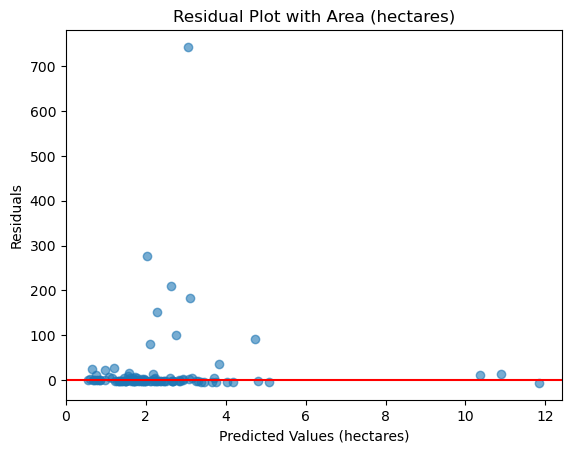

In [18]:

residuals_orig = y_test_orig - y_pred_orig
plt.scatter(y_pred_orig, residuals_orig, alpha=0.6)
plt.axhline(0, color='red')
plt.xlabel("Predicted Values (hectares)")
plt.ylabel("Residuals")
plt.title("Residual Plot with Area (hectares)")
plt.show()


- Residuals here stays close to 0 and some points with extreme values.
- The model behaved much more consistently in the log-transformed residual plot, showing more spread with less extreme points.

---

## Other Model Specifications

In this section, were trying to see if other model specifications would help create a better model thus producing better metrics.
- Model 2: Model Without log_area Outliers
- Model 3: Model Without Dummies

### Model 2: Without log_area Outliers

Even though the log transform helped with the skewness of our data, they still are far away from the rest of the data and can still affect our model. Keeping this will force our linear regression model to 'care' for big fires even if we didn't have enough data on it. The performance will end up being worse on majority of the fires.

"where a few rare, very large burns can disproportionately distort model fit. This"

In [19]:
upper = df["log_area"].quantile(0.99)
df_2 = df[df["log_area"] <= upper] # drop rows above the cutoff 

features = df_2.columns.drop(['log_area', 'area']).tolist()

X = df_2[features]
y = df_2['log_area'] # after removing outliers

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

scaler.fit(X_train[continuous_features])

X_train_scaled[continuous_features] = scaler.transform(X_train[continuous_features])
X_test_scaled[continuous_features] = scaler.transform(X_test[continuous_features])

In [21]:
model2 = LinearRegression() 
model2.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [22]:
y_pred = model2.predict(X_test_scaled)

r_squared_2 = r2_score(y_test, y_pred)
mse_2 = mean_squared_error(y_test, y_pred)
rmse_2 = np.sqrt(mse_2)

print("Linear Regression Metrics")
print("R^2: ", r_squared_2)
print("MSE: ", mse_2)
print("RMSE: ", rmse_2)

Linear Regression Metrics
R^2:  -0.029311679082562492
MSE:  1.6634191713360345
RMSE:  1.289736085924572


- Removing outliers made the R^2 worse, could be because the few outliers removed were the only ones that actually contained some variance in the target.

### Model 3: Model Without Dummies

In [23]:
no_dummy_features = ['FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind']

X = df[no_dummy_features]
y = df['log_area'] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
model3 = LinearRegression() 
model3.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
y_pred = model3.predict(X_test_scaled)

r_squared_3 = r2_score(y_test, y_pred)
mse_3 = mean_squared_error(y_test, y_pred)
rmse_3 = np.sqrt(mse_3)

print("Linear Regression Metrics")
print("R^2: ", r_squared_3)
print("MSE: ", mse_3)
print("RMSE: ", rmse_3)

Linear Regression Metrics
R^2:  0.02920269972820999
MSE:  2.460239201090162
RMSE:  1.5685149668046403


- Still not better, even after adding back the rest of the log_area outliers. The month feature added small signals/information and variation, the rest of the predictors left predict fire risk and not burned area. Months helped a little by giving some info about season, when wind would pick up, whats the temp during what months, 

---

## Notebook Summary
The best linear regression model we have was still the first one based on their R^2 values:
- Model 1 = 0.04
- Model 2 = -0.03
- Model 3 = 0.03

Since Model 1 performed the best out of the three models we created, we did a deeper analysis by inspecting its coefficients and check for signs of overfitting.
This model consists of 7 features and dummies for the month feature, with 509 rows of data. 

Removal of outlier or dummies made the model perform worse as it removed some signals or variations that could have helped with more accurate prediction.

Although log-transforming the area barely changed the correlation between different features, its still helped us make the skewness better and stabilizing the variance.
This transformation helped us make better sense of the data to analyze and reduce extreme values to better understand meaningful patterns in our data.

The model performed as expected with all the noise and skewness. Possible explorations in the future could be:
- combining features
- analyzing based on seasons
- checking the terrains/vegetations using X,Y coordinates and see if these will help us create a better model for predicting the area of forest fires

The project ultimately shows the limited predictive powers for estimating burned area using linear regression. Even after exploring, cleaning and engineering the data, the model still struggled to find meaningful relationships.